#1. MOUNT DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#2. INSTALL DEPENDENCIES

In [ ]:
!pip install -q timm facenet-pytorch moviepy librosa
!pip install -q dlib
print("Dependencies installed")
print("Restart Session")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 965.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 723.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124

#3. IMPORTS

In [ ]:
import os
import cv2
import gc
import math
import librosa
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dlib

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import timm
from torchvision import transforms

import tensorflow as tf

from facenet_pytorch import MTCNN

from moviepy.editor import VideoFileClip

warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

#4. DEFINE PATHS

In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/Multimodal_Deepfake_Project"

VIDEO_DIR = os.path.join(PROJECT_DIR, "video_assets")
AUDIO_DIR = os.path.join(PROJECT_DIR, "audio_assets")
IMAGE_DIR = os.path.join(PROJECT_DIR, "image_assets")

TEMP_DIR = os.path.join(PROJECT_DIR, "temp")

os.makedirs(TEMP_DIR, exist_ok=True)

print("Paths ready")

Paths ready


#5. DEVICE SETUP

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

Using device: cpu


#6. VIDEO TRANSFORM

In [ ]:
video_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Video transform ready")

Video transform ready


#7. LOAD VIDEO MODEL

In [ ]:
video_model = timm.create_model(
    "resnext101_32x8d",
    pretrained=False,
    num_classes=2
)

video_model.load_state_dict(
    torch.load(
        os.path.join(
            VIDEO_DIR,
            "improved_video_model.pth"
        ),
        map_location=device
    )
)

video_model = video_model.to(device)

video_model.eval()

print("Improved video model loaded successfully")

Improved video model loaded successfully


#8. LOAD AUDIO MODEL

In [ ]:
audio_model = tf.keras.models.load_model(
    os.path.join(
        AUDIO_DIR,
        "best_audio_model.keras"
    )
)

print("Audio model loaded successfully")

Audio model loaded successfully


#9. LOAD IMAGE MODEL

In [ ]:
import joblib

image_model = joblib.load(
    os.path.join(
        IMAGE_DIR,
        "svm_efficientnet_b4.pkl"
    )
)

image_pca = joblib.load(
    os.path.join(
        IMAGE_DIR,
        "pca_efficientnet_b4.pkl"
    )
)

print("Image model loaded successfully")

Image model loaded successfully


#10. LOAD FACE DETECTOR

In [ ]:
mtcnn = MTCNN(
    keep_all=False,
    device=device
)

print("MTCNN ready")

MTCNN ready


#LOAD DLIB DETECTOR

In [ ]:
detector = dlib.get_frontal_face_detector()

predictor = dlib.shape_predictor(
    os.path.join(
        IMAGE_DIR,
        "shape_predictor_68_face_landmarks.dat"
    )
)

print("Dlib landmark detector ready")

Dlib landmark detector ready


#11. VERIFY ALL MODELS

In [ ]:
print("\n========== MODEL STATUS ==========")

print("Video model  :", type(video_model))
print("Audio model  :", type(audio_model))
print("Image model  :", type(image_model))

print("==================================")


========== MODEL STATUS ==========
Video model  : <class 'timm.models.resnet.ResNet'>
Audio model  : <class 'keras.src.models.sequential.Sequential'>
Image model  : <class 'sklearn.svm._classes.LinearSVC'>


#12. VIDEO FRAME EXTRACTION

In [ ]:
def extract_frames(
    video_path,
    num_frames=16
):

    cap = cv2.VideoCapture(video_path)

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if total_frames <= 0:
        return []

    frame_idxs = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=int
    )

    frames = []

    for idx in frame_idxs:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            idx
        )

        success, frame = cap.read()

        if success:

            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            frames.append(frame)

    cap.release()

    return frames

#13. FACE EXTRACTION

In [ ]:
def extract_faces(
    frames
):

    face_crops = []

    for frame in frames:

        pil_img = Image.fromarray(frame)

        face = mtcnn(pil_img)

        if face is not None:

            face_crops.append(face)

    return face_crops

#14. VIDEO PREDICTION

In [ ]:
def predict_video(
    face_crops
):

    if len(face_crops) == 0:

      return {
    "video_score": 0.5,
    "video_confidence": 0.0,
    "video_reliability": "LOW",
    "fake_ratio": 0.0,
    "frame_probs": []
}



    probs = []

    with torch.no_grad():

        for face in face_crops:

            face = face.unsqueeze(0).to(device)

            logits = video_model(face)

            temperature = 1.5

            prob = torch.softmax(
                logits / temperature,
                dim=1
                )[0][1].item()

            probs.append(prob)

    probs = np.array(probs)

    fake_ratio = np.mean(probs > 0.5)

    video_score = float(np.mean(probs))

    confidence = float(
        np.mean(
            np.abs(probs - 0.5)
        ) * 2
    )

    # =========================
    # Reliability Logic
    # =========================

    if len(face_crops) >= 12 and confidence > 0.6:
        reliability = "HIGH"

    elif len(face_crops) >= 6:
        reliability = "MEDIUM"

    else:
        reliability = "LOW"

    return {

        "video_score": video_score,
        "video_confidence": confidence,
        "video_reliability": reliability,
        "fake_ratio": float(fake_ratio),
        "frame_probs": probs.tolist()
    }

#15. TEST VIDEO PIPELINE

In [ ]:
print("Video pipeline ready")

Video pipeline ready


#16. VIDEO UPLOAD TEST

In [ ]:
from google.colab import files

print("Upload video for testing...")

uploaded = files.upload()

video_path = list(uploaded.keys())[0]

print(f"\nUploaded: {video_path}")

Upload video for testing...


Saving fake_audio_098.flac to fake_audio_098.flac

Uploaded: fake_audio_098.flac


#17. RUN VIDEO ANALYSIS

In [ ]:
print("\n[VIDEO PIPELINE] Extracting frames...")

frames = extract_frames(
    video_path,
    num_frames=16
)

print(f"Frames extracted: {len(frames)}")

print("\n[VIDEO PIPELINE] Extracting faces...")

faces = extract_faces(frames)

print(f"Faces extracted: {len(faces)}")

print("\n[VIDEO PIPELINE] Running prediction...")

video_result = predict_video(faces)

print("\n========== VIDEO ANALYSIS ==========")

print(
    f"Video Score       : "
    f"{video_result['video_score']:.4f}"
)

print(
    f"Video Confidence  : "
    f"{video_result['video_confidence']:.4f}"
)

print(
    f"Fake Frame Ratio  : "
    f"{video_result['fake_ratio']:.2%}"
)

print(
    f"Reliability       : "
    f"{video_result['video_reliability']}"
)

verdict = (
    "FAKE"
    if video_result["video_score"] >= 0.5
    else "REAL"
)

print(f"\nVIDEO VERDICT : {verdict}")

print("====================================")


[VIDEO PIPELINE] Extracting frames...
Frames extracted: 0

[VIDEO PIPELINE] Extracting faces...
Faces extracted: 0

[VIDEO PIPELINE] Running prediction...

========== VIDEO ANALYSIS ==========
Video Score       : 0.5000
Video Confidence  : 0.0000
Fake Frame Ratio  : 0.00%
Reliability       : LOW

VIDEO VERDICT : FAKE


#18. VISUALIZE FRAME SCORES

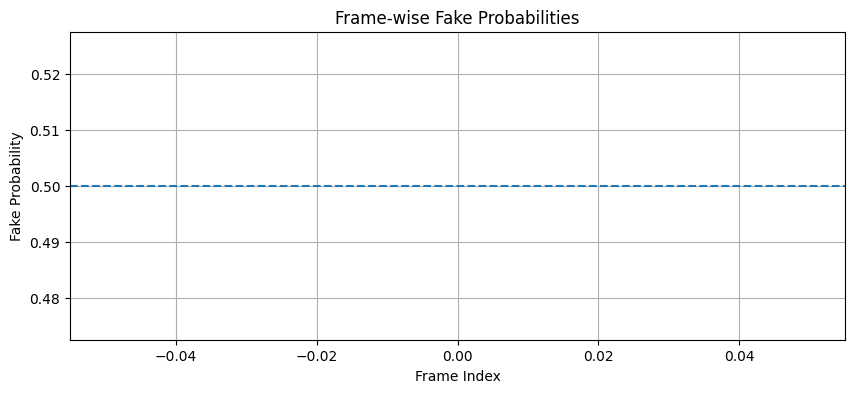

In [ ]:
frame_probs = video_result["frame_probs"]

plt.figure(figsize=(10, 4))

plt.plot(
    frame_probs,
    marker='o'
)

plt.axhline(
    0.5,
    linestyle='--'
)

plt.title("Frame-wise Fake Probabilities")

plt.xlabel("Frame Index")
plt.ylabel("Fake Probability")

plt.grid(True)

plt.show()

#19.IMAGE FEATURE EXTRACTOR

In [ ]:
image_feature_extractor = timm.create_model(
    "efficientnet_b4",
    pretrained=True,
    num_classes=0
)

image_feature_extractor = image_feature_extractor.to(device)
image_feature_extractor.eval()

print("Image feature extractor ready")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Image feature extractor ready


#20. IMAGE TRANSFORM

In [ ]:
image_transform = transforms.Compose([

    transforms.Resize((380, 380)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transform ready")

Image transform ready


#21. SELECT SUSPICIOUS FRAMES

In [ ]:
def select_suspicious_frames(
    frames,
    frame_probs,
    top_k=3
):

    idxs = np.argsort(frame_probs)[::-1][:top_k]

    suspicious = []

    for idx in idxs:

        suspicious.append(
            (
                frames[idx],
                frame_probs[idx]
            )
        )

    return suspicious

#22. IMAGE MODEL PREDICTION

In [ ]:
FACIAL_REGIONS = {
    "jaw"            : list(range(0, 17)),
    "right_eyebrow"  : list(range(17, 22)),
    "left_eyebrow"   : list(range(22, 27)),
    "nose"           : list(range(27, 36)),
    "right_eye"      : list(range(36, 42)),
    "left_eye"       : list(range(42, 48)),
    "mouth"          : list(range(48, 68))
}

def extract_landmark_features(frame):

    gray = cv2.cvtColor(
        frame,
        cv2.COLOR_RGB2GRAY
    )

    faces = detector(gray, 1)

    if len(faces) == 0:
        return np.zeros(136, dtype=np.float32)

    face = max(
        faces,
        key=lambda r: r.width() * r.height()
    )

    landmarks = predictor(gray, face)

    h, w = gray.shape

    features = []

    for region in FACIAL_REGIONS.values():

        for i in region:

            x = landmarks.part(i).x / w
            y = landmarks.part(i).y / h

            features.extend([x, y])

    return np.array(
        features,
        dtype=np.float32
    )


def predict_image_frame(frame):

    image = Image.fromarray(frame)

    x = image_transform(image)

    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        deep_features = image_feature_extractor(x)

    deep_features = deep_features.cpu().numpy()[0]

    landmark_features = extract_landmark_features(frame)

    combined_features = np.concatenate([
        deep_features,
        landmark_features
    ])

    combined_features = combined_features.reshape(1, -1)

    features_pca = image_pca.transform(
        combined_features
    )

    pred = image_model.decision_function(
        features_pca
    )[0]

    prob = 1 / (1 + np.exp(-pred))

    return float(prob)

#23. IMAGE ANALYSIS ENGINE

In [ ]:
def analyze_suspicious_frames(
    suspicious_frames
):

    image_scores = []

    for frame, vid_prob in suspicious_frames:

        img_prob = predict_image_frame(frame)

        image_scores.append(img_prob)

    image_scores = np.array(image_scores)

    image_score = float(
        np.mean(image_scores)
    )

    confidence = float(
        np.mean(
            np.abs(image_scores - 0.5)
        ) * 2
    )

    if confidence > 0.7:
        reliability = "HIGH"

    elif confidence > 0.4:
        reliability = "MEDIUM"

    else:
        reliability = "LOW"

    return {

        "image_score": image_score,
        "image_confidence": confidence,
        "image_reliability": reliability,
        "image_scores": image_scores
    }

#24. RUN IMAGE-ASSISTED ANALYSIS

In [ ]:
print("\n[IMAGE BRANCH] Selecting suspicious frames...")

suspicious_frames = select_suspicious_frames(
    frames,
    video_result["frame_probs"],
    top_k=3
)

print(
    f"Suspicious frames selected: "
    f"{len(suspicious_frames)}"
)

print("\n[IMAGE BRANCH] Running image analysis...")

image_result = analyze_suspicious_frames(
    suspicious_frames
)

print("\n========== IMAGE ANALYSIS ==========")

print(
    f"Image Score       : "
    f"{image_result['image_score']:.4f}"
)

print(
    f"Image Confidence  : "
    f"{image_result['image_confidence']:.4f}"
)

print(
    f"Reliability       : "
    f"{image_result['image_reliability']}"
)

image_verdict = (
    "FAKE"
    if image_result["image_score"] >= 0.5
    else "REAL"
)

print(f"\nIMAGE VERDICT : {image_verdict}")

print("====================================")


[IMAGE BRANCH] Selecting suspicious frames...
Suspicious frames selected: 0

[IMAGE BRANCH] Running image analysis...

========== IMAGE ANALYSIS ==========
Image Score       : nan
Image Confidence  : nan
Reliability       : LOW

IMAGE VERDICT : REAL


#ADAPTIVE VISUAL FUSION

In [ ]:
def adaptive_visual_fusion(
    video_result,
    image_result
):

    video_score = video_result["video_score"]
    video_conf  = video_result["video_confidence"]
    fake_ratio  = video_result["fake_ratio"]

    image_score = image_result["image_score"]
    image_conf  = image_result["image_confidence"]

    # =========================
    # Reliability weights
    # =========================

    video_weight = 0.85
    image_weight = 0.15

    # =========================
    # Suppress weak image branch
    # =========================

    if image_conf < 0.08:
        image_weight *= 0.3

    # =========================
    # Strong fake escalation
    # =========================

    if video_score > 0.75 and fake_ratio > 0.70:

        final_score = (
            0.95 * video_score +
            0.05 * image_score
        )

        verdict = "FAKE"

        risk = "HIGH"

    # =========================
    # Suspicious zone reasoning
    # =========================

    elif video_score > 0.18 or fake_ratio > 0.18:

        suspicious_boost = (
            fake_ratio * 0.25
        )

        final_score = (

            video_weight * video_score +

            image_weight * image_score +

            suspicious_boost
        )

        if final_score >= 0.45:

            verdict = "SUSPICIOUS"

            risk = "MEDIUM"

        else:

            verdict = "LIKELY_REAL"

            risk = "LOW"

    # =========================
    # Strong real zone
    # =========================

    else:

        final_score = (

            video_weight * video_score +

            image_weight * image_score
        )

        verdict = "REAL"

        risk = "LOW"

        # =========================
        # CLAMP SCORE
        # =========================

        final_score = np.clip(
            final_score,
            0,
            1
            )

    return {

        "final_score": float(final_score),
        "verdict": verdict,
        "risk": risk
    }

#RUN VISUAL FUSION

In [ ]:
fusion_result = adaptive_visual_fusion(
    video_result,
    image_result
)

print("\n========== VISUAL FUSION ==========")

print(
    f"Final Score : "
    f"{fusion_result['final_score']:.4f}"
)

print(
    f"Verdict     : "
    f"{fusion_result['verdict']}"
)

print(
    f"Risk Level  : "
    f"{fusion_result['risk']}"
)

print("===================================")


========== VISUAL FUSION ==========
Final Score : nan
Verdict     : LIKELY_REAL
Risk Level  : LOW


#AUDIO EXTRACTION

In [ ]:
def extract_audio_from_video(
    video_path,
    output_audio="temp_audio.wav"
):

    try:

        clip = VideoFileClip(video_path)

        if clip.audio is None:

            print("No audio track found")

            clip.close()

            return None

        clip.audio.write_audiofile(
            output_audio,
            verbose=False,
            logger=None
        )

        # =====================================
        # CLOSE CLIP (IMPORTANT)
        # =====================================

        clip.close()

        return output_audio

    except Exception as e:

        print(f"Audio extraction failed: {e}")

        return None

#AUDIO PREDICTION FUNCTION

In [ ]:
def predict_audio_deepfake(
    audio_path
):

    audio, sr = librosa.load(
        audio_path,
        sr=TARGET_SR
    )

    # =========================
    # Normalize
    # =========================

    if np.max(np.abs(audio)) > 0:

        audio = (
            audio /
            np.max(np.abs(audio))
        )

    # =========================
    # Fixed length
    # =========================

    if len(audio) > MAX_LEN:

        audio = audio[:MAX_LEN]

    else:

        audio = np.pad(
            audio,
            (0, MAX_LEN - len(audio))
        )

    # =========================
    # Mel Spectrogram
    # =========================

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=N_MELS
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    # =========================
    # Resize
    # =========================

    if mel_db.shape[1] < MAX_PAD:

        mel_db = np.pad(
            mel_db,
            (
                (0,0),
                (0, MAX_PAD - mel_db.shape[1])
            )
        )

    else:

        mel_db = mel_db[:, :MAX_PAD]

    # =========================
    # Normalize
    # =========================

    mel_db = (
        mel_db - mel_db.mean()
    ) / (
        mel_db.std() + 1e-6
    )

    x = np.expand_dims(
        mel_db,
        axis=-1
    )

    x = np.expand_dims(
        x,
        axis=0
    )

    # =========================
    # Predict
    # =========================
    pred = audio_model.predict(
        x,
        verbose=0
    )[0][0]

    # =========================
    # Temperature Scaling
    # =========================


    temperature = 1.8
    pred = np.clip(
        pred,
        1e-6,
        1 - 1e-6
        )
    pred = pred ** (1 / temperature)


    confidence = abs(
        pred - 0.5
    ) * 2

    if confidence > 0.7:
        reliability = "HIGH"

    elif confidence > 0.4:
        reliability = "MEDIUM"

    else:
        reliability = "LOW"

    verdict = (
        "FAKE"
        if pred >= best_thresh
        else "REAL"
    )

    return {

        "audio_score": float(pred),
        "audio_confidence": float(confidence),
        "audio_reliability": reliability,
        "audio_verdict": verdict
    }

# AUDIO CONFIG

In [ ]:
# =====================================
# AUDIO CONFIG
# =====================================

TARGET_SR = 16000

MAX_LEN = 4 * TARGET_SR

MAX_PAD = 128

N_MELS = 64

best_thresh = 0.5

print("Audio config loaded")

Audio config loaded


#RUN AUDIO ANALYSIS

In [ ]:
print("\n[AUDIO PIPELINE] Extracting audio...")

audio_path = extract_audio_from_video(
    video_path
)

print(
    f"Audio extracted: "
    f"{audio_path}"
)

# =====================================
# SAFE AUDIO ANALYSIS
# =====================================

if audio_path is not None:

    print("\n[AUDIO PIPELINE] Running prediction...")

    audio_result = predict_audio_deepfake(
        audio_path
    )

else:

    print(
        "\n[AUDIO PIPELINE] "
        "Audio extraction failed"
    )

    audio_result = {

        "audio_score": 0.5,

        "audio_confidence": 0.0,

        "audio_reliability": "LOW",

        "audio_verdict": "UNKNOWN"
    }

# =====================================
# PRINT RESULTS
# =====================================

print("\n========== AUDIO ANALYSIS ==========")

print(
    f"Audio Score       : "
    f"{audio_result['audio_score']:.4f}"
)

print(
    f"Audio Confidence  : "
    f"{audio_result['audio_confidence']:.4f}"
)

print(
    f"Reliability       : "
    f"{audio_result['audio_reliability']}"
)

print(
    f"\nAUDIO VERDICT : "
    f"{audio_result['audio_verdict']}"
)

print("====================================")


[AUDIO PIPELINE] Extracting audio...
Audio extraction failed: 'video_fps'
Audio extracted: None

[AUDIO PIPELINE] Audio extraction failed

========== AUDIO ANALYSIS ==========
Audio Score       : 0.5000
Audio Confidence  : 0.0000
Reliability       : LOW

AUDIO VERDICT : UNKNOWN


#FINAL GLOBAL FUSION ENGINE

In [ ]:
def final_multimodal_fusion(
    video_result,
    image_result,
    visual_result,
    audio_result
):

    visual_score = visual_result["final_score"]

    audio_score = audio_result["audio_score"]

    video_reliability = (
        video_result["video_reliability"]
    )

    audio_reliability = (
        audio_result["audio_reliability"]
    )

    # =====================================
    # BASE WEIGHTS
    # =====================================

    video_weight = 0.75

    audio_weight = 0.15

    image_weight = 0.0

    # =====================================
    # AUDIO RELIABILITY ADJUSTMENT
    # =====================================

    if audio_reliability == "LOW":

        audio_weight *= 0.5

    elif audio_reliability == "MEDIUM":

        audio_weight *= 0.75

    # =====================================
    # VIDEO RELIABILITY BOOST
    # =====================================

    if video_reliability == "HIGH":

        video_weight *= 1.1

    elif video_reliability == "MEDIUM":

        video_weight *= 1.0

    else:

        video_weight *= 0.8

    # =====================================
    # NORMALIZE
    # =====================================

    total = (
        video_weight +
        audio_weight +
        image_weight
    )

    video_weight /= total

    audio_weight /= total

    image_weight /= total

    # =====================================
    # GATED MODALITY CONTROL
    # =====================================

    # Reduce video influence if confidence unstable

    if (
        video_result["video_confidence"] < 0.45
    ):

        video_weight *= 0.85

    # Reduce audio influence if uncertain

    if (
        audio_result["audio_confidence"] < 0.60
    ):

        audio_weight *= 0.75

    # Reduce image influence if disagreement high

    if (
        abs(

            video_result["video_score"] -

            image_result["image_score"]

        ) > 0.45
    ):

        image_weight *= 0.5

    # =====================================
    # GLOBAL SCORE
    # =====================================

    final_score = (

        visual_score * video_weight +

        audio_score * audio_weight +

        image_result["image_score"] * image_weight
    )

    # =====================================
    # AUDIO-VISUAL CONSISTENCY
    # =====================================

    consistency_gap = abs(

        visual_result["final_score"] -

        audio_result["audio_score"]

    )

    if consistency_gap > 0.55:

        manipulation_type = (
            "MODALITY MISMATCH"
        )

        final_score += 0.05

    # =====================================
    # CROSS-MODAL LOGIC
    # =====================================

    manipulation_type = "NONE"

    if (
        visual_score > 0.6 and
        audio_score > 0.7
    ):

        manipulation_type = "VISUAL + AUDIO"

        final_score += 0.08

    elif (
        visual_score > 0.6 and
        audio_score < 0.4
    ):

        manipulation_type = "VISUAL ONLY"

        final_score += 0.04

    elif (
        visual_score < 0.45 and
        audio_score > 0.8
    ):

        manipulation_type = "AUDIO ONLY"

        final_score += 0.03

    elif (
        0.4 <= visual_score <= 0.6 and
        audio_score > 0.7
    ):

        manipulation_type = "LIKELY HYBRID"

        final_score += 0.05

    # =====================================
    # STRONG AUDIO-ONLY ESCALATION
    # =====================================

    if (
        visual_score < 0.35 and
        audio_score > 0.95 and
        audio_reliability == "HIGH"
    ):

        final_score += 0.08

    # =====================================
    # CLAMP
    # =====================================

    final_score = np.clip(
        final_score,
        0,
        1
    )

    # =====================================
    # SMART THRESHOLDS
    # =====================================

    if final_score >= 0.70:

        verdict = "FAKE"

    elif final_score >= 0.50:

        verdict = "SUSPICIOUS"

    else:

        verdict = "REAL"

    # =====================================
    # RISK LEVEL
    # =====================================

    if final_score >= 0.72:

        risk = "HIGH"

    elif final_score >= 0.55:

        risk = "MEDIUM"

    else:

        risk = "LOW"

    # =====================================
    # EXPLANATION
    # =====================================

    explanation = []

    if visual_score > 0.6:

        explanation.append(
            "Strong visual manipulation evidence"
        )

    elif visual_score > 0.4:

        explanation.append(
            "Moderate visual anomalies detected"
        )

    if audio_score > 0.8:

        explanation.append(
            "Synthetic speech patterns detected"
        )

    elif audio_score > 0.6:

        explanation.append(
            "Suspicious audio characteristics"
        )

    if (
        visual_score < 0.4 and
        audio_score > 0.8
    ):

        explanation.append(
            "Possible AI narration or voice cloning"
        )

    if (
        visual_score > 0.6 and
        audio_score < 0.4
    ):

        explanation.append(
            "Possible visual-only manipulation"
        )

    if len(explanation) == 0:

        explanation.append(
            "No major manipulation evidence detected"
        )

    return {

        "global_score": float(final_score),

        "verdict": verdict,

        "risk": risk,

        "manipulation_type": manipulation_type,

        "explanation": explanation,

        "video_weight": float(video_weight),

        "audio_weight": float(audio_weight)
    }

#final result

In [ ]:
global_result = final_multimodal_fusion(
    video_result,
    image_result,
    fusion_result,
    audio_result
)

print("\n========== FINAL MULTIMODAL ANALYSIS ==========\n")

print(
    f"Global Score      : "
    f"{global_result['global_score']:.4f}"
)

print(
    f"Final Verdict     : "
    f"{global_result['verdict']}"
)

print(
    f"Risk Level        : "
    f"{global_result['risk']}"
)

print(
    f"Manipulation Type : "
    f"{global_result['manipulation_type']}"
)

print("\nExplanation:")

for e in global_result["explanation"]:

    print(f"- {e}")

print("\nWeights Used:")

print(
    f"- Video Weight : "
    f"{global_result['video_weight']:.3f}"
)

print(
    f"- Audio Weight : "
    f"{global_result['audio_weight']:.3f}"
)

print("\n==============================================")


========== FINAL MULTIMODAL ANALYSIS ==========

Global Score      : nan
Final Verdict     : REAL
Risk Level        : LOW
Manipulation Type : NONE

Explanation:
- No major manipulation evidence detected

Weights Used:
- Video Weight : 0.756
- Audio Weight : 0.083

